# Markov Processes: HW 3
**Name:** Jacob Mejia 
**Date:** September 15, 2026
## 1. A stepping motor as three state cycle.
### c) Computation
Compute $p^{50}$ numericaly numerically. You should find that all three rows agree to the digits printed. Call that common row $f = (fW , fC , fS )$, the long run fraction of time the motor spends in each state, and check that f agrees with the dwell times of part (b) divided by the mean cycle time.

In [1]:
import numpy as np

p_w = np.array([9/10, 1/10, 0])
p_c = np.array([0, 3/4, 1/4])
p_s = np.array([1/2, 0, 1/2])

p = np.array([p_w, p_c, p_s])

print(p)

[[0.9  0.1  0.  ]
 [0.   0.75 0.25]
 [0.5  0.   0.5 ]]


In [2]:
p_app = np.linalg.matrix_power(p, 50)

print(p_app)

[[0.625 0.25  0.125]
 [0.625 0.25  0.125]
 [0.625 0.25  0.125]]


In [3]:
t_cycle = 16
dwell_times = np.array([10, 4, 2])

f_div = dwell_times / t_cycle

print("From dwell times:", f_div)
print("From P^50:", p_app[0])

From dwell times: [0.625 0.25  0.125]
From P^50: [0.625 0.25  0.125]


They agree.

### c) The mean return time
The mean return time to a state, meaning the mean number of steps from a visit to $W$ until the next visit to $W$, is the reciprocal $1/fW$ of its long run fraction. You may use that fact here. It gives a mean return time of $1.6$ ms, while part (b) gave a mean cycle time of $16$ ms. Reconcile these two numbers.

In [4]:
recip = 1/f_div[0] 

print("The mean number of steps from a visit to W until the next visit to W, is the reciprocal 1/fW:",recip ,"ms")

The mean number of steps from a visit to W until the next visit to W, is the reciprocal 1/fW: 1.6 ms


since fw = dwell_times / t_cycle = 10/16 = 0.625 then 1/fw = 1.6 ms. Then this implies that the expected 

## 2. c) Return probability and expected visits

Return to state 1 occurs only via an immediate self-loop or the path through state 2:

$$
\rho_{11}=p_{11}+p_{12}p_{21}
=\frac12+\frac12\cdot\frac13=\frac23.
$$

The total visits, including the initial visit, are geometric:

$$
\mathbb E_1[V]=\frac{1}{1-\rho_{11}}=3.
$$

**Conclusion:** State 1 is transient because its return probability is less than one.


## 4. Capture of the lamb
### b) One lion

For a power-law tail,

$$
\mathbb E[\tau]=\sum_{t\geq0}S_1(t)=\infty,\qquad S_1(t)\sim Ct^{-\beta_1}.
$$

The p-series converges if the exponent exceeds one, so

$$
0<\beta_1\leq1.
$$

Thus a power-law survival tail cannot decay faster than the reciprocal of time.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from IPython.display import display, Markdown

R, T, d0 = 20_000, 10_000, 10

def simulate_survival(n_lions, seed):
    rng = np.random.default_rng(seed)
    lamb = np.zeros(R, dtype=np.int32)
    lions = np.full((R, n_lions), d0, dtype=np.int32)
    alive = np.ones(R, dtype=bool)
    survival = np.empty(T + 1)
    survival[0] = 1.0
    for t in range(1, T + 1):
        # Vectorize across realizations; already captured paths stay dead.
        lamb += 2 * rng.integers(0, 2, size=R, dtype=np.int32) - 1
        lions += 2 * rng.integers(0, 2, size=(R, n_lions), dtype=np.int32) - 1
        alive &= ~np.any(lions == lamb[:, None], axis=1)
        survival[t] = alive.mean()
    return survival

S1 = simulate_survival(1, seed=41001)
times = np.arange(T + 1)

def fit_power_law(survival):
    window = (times >= 100) & (times <= 10_000)
    keep = window & (survival > 0)
    slope, intercept = np.polyfit(np.log(times[keep]), np.log(survival[keep]), 1)
    return -slope, intercept, int(np.count_nonzero(window & ~keep))

beta1, intercept1, excluded1 = fit_power_law(S1)
print(f"One lion: beta1 = {beta1:.4f}; zero-survival fit points excluded = {excluded1}")

One lion: beta1 = 0.4846; zero-survival fit points excluded = 0


### b), c) Combined plot and table

Use 20,000 runs, 10,000 steps, and initial separation 10. Fit

$$
\log\widehat S_N(t)=a_N-\widehat\beta_N\log t,\qquad 10^2\leq t\leq10^4.
$$

Overlay the prediction (no fitted prefactor):

$$
S_{1,\mathrm{cont}}(t)=\operatorname{erf}\!\left(\frac{10}{2\sqrt t}\right).
$$

Exclude zero survival estimates from logarithms; none occurred. The squared curve uses simulated one-lion survival.


Two lions: beta2 = 0.7452; zero-survival fit points excluded = 0


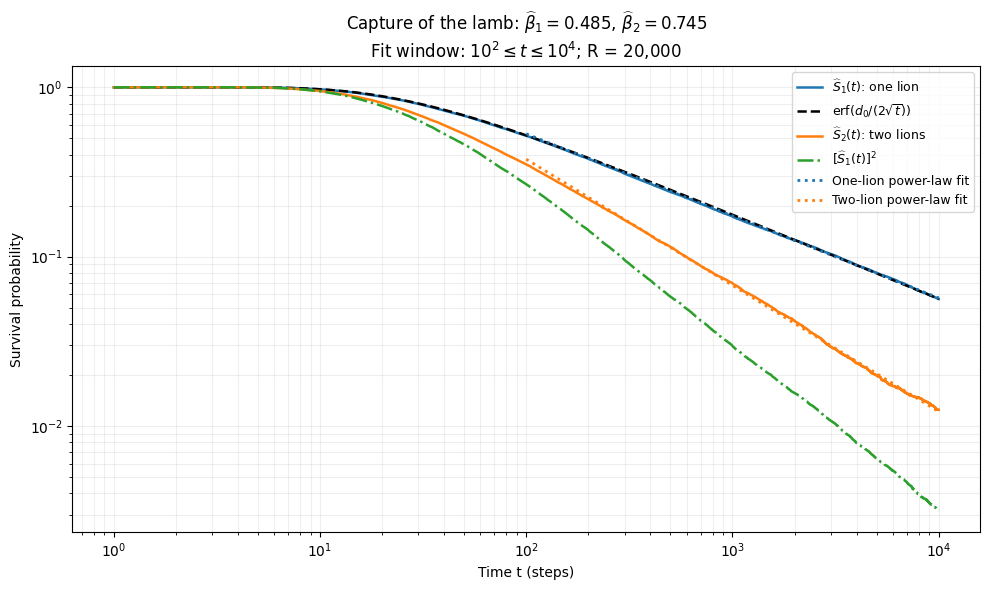

| Time (steps) | Two-lion survival | Squared one-lion survival |
|---:|---:|---:|
| 100 | 0.350950 | 0.267703 |
| 1,000 | 0.069700 | 0.029687 |
| 10,000 | 0.012450 | 0.003153 |


In [6]:
S2 = simulate_survival(2, seed=41002)
beta2, intercept2, excluded2 = fit_power_law(S2)
print(f"Two lions: beta2 = {beta2:.4f}; zero-survival fit points excluded = {excluded2}")

fig, ax = plt.subplots(figsize=(10, 6))
positive_times = times[1:]
for values, label, color, style in [
    (S1[1:], r"$\widehat S_1(t)$: one lion", 'tab:blue', '-'),
    (erf(d0 / (2 * np.sqrt(positive_times))), r"$\mathrm{erf}(d_0/(2\sqrt{t}))$", 'black', '--'),
    (S2[1:], r"$\widehat S_2(t)$: two lions", 'tab:orange', '-'),
    (S1[1:] ** 2, r"$[\widehat S_1(t)]^2$", 'tab:green', '-.'),
]:
    positive = values > 0
    ax.loglog(positive_times[positive], values[positive], style,
              color=color, label=label, linewidth=1.8)
fit_times = times[100:]
ax.loglog(fit_times, np.exp(intercept1) * fit_times ** (-beta1), ':',
          color='tab:blue', linewidth=2, label='One-lion power-law fit')
ax.loglog(fit_times, np.exp(intercept2) * fit_times ** (-beta2), ':',
          color='tab:orange', linewidth=2, label='Two-lion power-law fit')
ax.set(xlabel='Time t (steps)', ylabel='Survival probability',
       title=(rf'Capture of the lamb: $\widehat\beta_1={beta1:.3f}$, '
              rf'$\widehat\beta_2={beta2:.3f}$'
              '\n' + r'Fit window: $10^2 \leq t \leq 10^4$; R = 20,000'))
ax.grid(True, which='both', alpha=0.2)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

table = '| Time (steps) | Two-lion survival | Squared one-lion survival |\n|---:|---:|---:|\n'
for t in (100, 1000, 10000):
    table += f'| {t:,} | {S2[t]:.6f} | {S1[t] ** 2:.6f} |\n'
display(Markdown(table))

### c) Dependence and conclusion

Let the independent lamb and lion hops be

$$
\xi,\eta_1,\eta_2\in\{-1,1\},\qquad
\mathbb E[\xi]=\mathbb E[\eta_i]=0,\qquad
\operatorname{Var}(\xi)=\operatorname{Var}(\eta_i)=1.
$$

Then, by hand,

$$
\Delta D_i=\eta_i-\xi,\qquad
\operatorname{Cov}(\Delta D_1,\Delta D_2)=\operatorname{Var}(\xi)=1,
$$
$$
\operatorname{Var}(\Delta D_i)=2,\qquad
\operatorname{Corr}(\Delta D_1,\Delta D_2)=\frac{1}{\sqrt{2\cdot2}}=\frac12.
$$

Both separations share the lamb's hop. Favorable lamb paths help avoid both lions, so

$$
S_2(t)\geq S_1(t)^2.
$$

**Conclusion:** Two lions reduce survival, but the shared lamb motion makes squaring one-lion survival an underestimate. The fitted exponents are

$$
\widehat\beta_1=0.4846\approx\frac12,\qquad \widehat\beta_2=0.7452.
$$
